In [73]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph, START, END

In [74]:
class AgentState(TypedDict):
    number1: int
    operation1: str
    number2: int
    finalNumber1: int
    number3: int
    operation2: str
    number4: int
    finalNumber2: int

In [75]:
def adder1(state: AgentState) -> AgentState:
    """This node adds number1 and number2"""  
    state["finalNumber1"] = state["number1"] + state["number2"]
    return state

def adder2(state: AgentState) -> AgentState:
    """This node adds number3 and number4"""  
    state["finalNumber2"] = state["number3"] + state["number4"]
    return state

In [76]:
def subtracter1(state: AgentState) -> AgentState:
    """This node subtracts number1 and number2"""  
    state["finalNumber1"] = state["number1"] - state["number2"]
    return state

def subtracter2(state: AgentState) -> AgentState:
    """This node subtracts number3 and number4"""  
    state["finalNumber2"] = state["number3"] - state["number4"]
    return state

In [77]:
def decide_next_node1(state: AgentState) -> str:
    """This is the first node that will select the next node of the graph"""  
    if state["operation1"] == "+":
        return "addition_operation1"
    elif state["operation1"] == "-":
        return "subtraction_operation1"

def decide_next_node2(state: AgentState) -> str:
    """This is the second node that will select the next node of the graph"""  
    if state["operation2"] == "+":
        return "addition_operation2"
    elif state["operation2"] == "-":
        return "subtraction_operation2"

In [78]:
graph = StateGraph(AgentState)

graph.add_node("add_node1", adder1)
graph.add_node("subtract_node1",subtracter1)
graph.add_node("add_node2", adder2)
graph.add_node("subtract_node2",subtracter2)
graph.add_node("router1", lambda state:state)
graph.add_node("router2", lambda state:state)

graph.add_edge(START, "router1")

graph.add_conditional_edges(
    "router1",
    decide_next_node1,
    {
        "addition_operation1": "add_node1",
        "subtraction_operation1": "subtract_node1",
    }

)

graph.add_edge("add_node1", "router2")
graph.add_edge("subtract_node1", "router2")

graph.add_conditional_edges(
    "router2",
    decide_next_node2,
    {
        "addition_operation2": "add_node2",
        "subtraction_operation2": "subtract_node2",
    }

)

graph.add_edge("add_node2", END)
graph.add_edge("subtract_node2", END)

app = graph.compile()

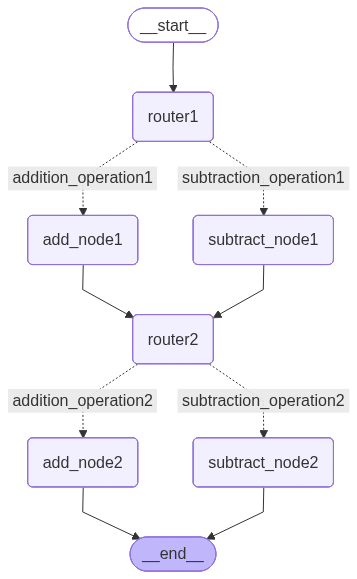

In [79]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [80]:
app.invoke({"number1": 9, "operation1": "-", "number2": 10, "number3": 6, "number4": 7, "operation2": "+"})

{'number1': 9,
 'operation1': '-',
 'number2': 10,
 'finalNumber1': -1,
 'number3': 6,
 'operation2': '+',
 'number4': 7,
 'finalNumber2': 13}